### Step 1: Load the Libraies and Data

In [571]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math
import random
import os
import time
import seaborn as sns
from math import sqrt
from PyEMD import EMD
import ewtpy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [572]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [573]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [574]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [575]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [576]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [577]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


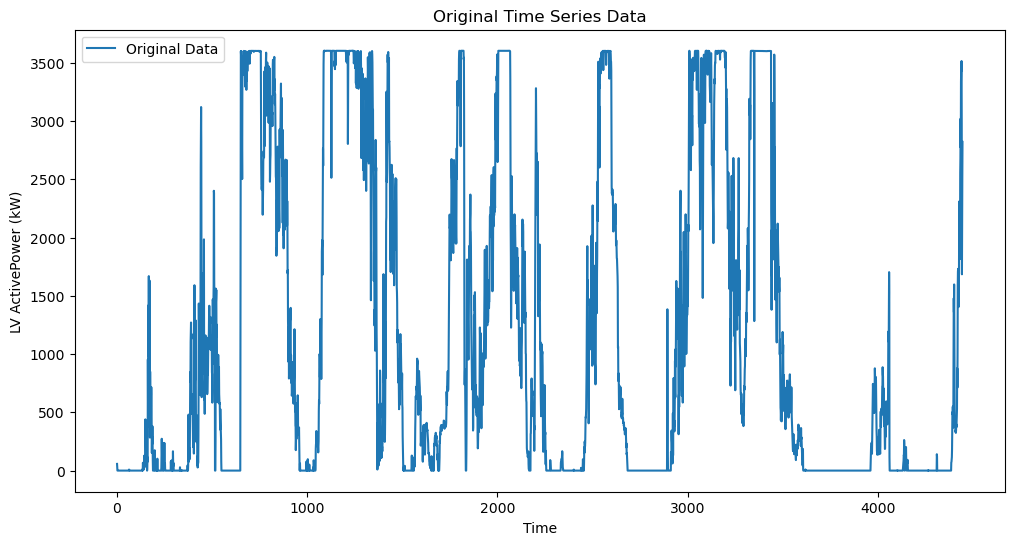

In [578]:
# Convert 'i' to a list and select data for the specified month
x = [1]
data1 = data.loc[data['Month'].isin(x)].reset_index(drop=True).dropna()
datas = data1['LV ActivePower (kW)']
dfs = datas.copy()
s = dfs.values.reshape(-1, 1)

# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(dfs.index, dfs.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()


In [579]:
s.shape

(4447, 1)

In [580]:
datas.shape

(4447,)

In [581]:
from PyEMD import EMD,EEMD,CEEMDAN
import ewtpy
# Perform CEEMDAN decomposition
emd = CEEMDAN(epsilon=0.05)
emd.noise_seed(12345)
s = s.flatten()  # Ensure s is a 1D array
IMFs = emd(s)

full_imf = pd.DataFrame(IMFs).T
ceemdan1 = full_imf

# Extract the first IMF
imf1 = ceemdan1.iloc[:, 0]
imf_dataps = np.array(imf1)
imf_datasetss = imf_dataps.reshape(-1, 1)
imf_new_datasets = pd.DataFrame(imf_datasetss)

# Perform EWT decomposition on the first IMF
ewt_coeffs, mfb, boundaries = ewtpy.EWT1D(imf1, N=3)
df_ewt = pd.DataFrame(ewt_coeffs)

# Remove the third column if it exists
if df_ewt.shape[1] > 2:
    df_ewt.drop(df_ewt.columns[2], axis=1, inplace=True)

# Sum the EWT components to get the denoised signal
denoised = df_ewt.sum(axis=1, skipna=True)

# Prepare the new CEEMDAN components by replacing the first IMF with the denoised signal
ceemdan_without_imf1 = ceemdan1.iloc[:, 1:].reset_index(drop=True)
denoised = denoised.reset_index(drop=True)
new_ceemdan = pd.concat([denoised, ceemdan_without_imf1], axis=1)
new_ceemdan.columns = range(new_ceemdan.shape[1])  # Reset column names

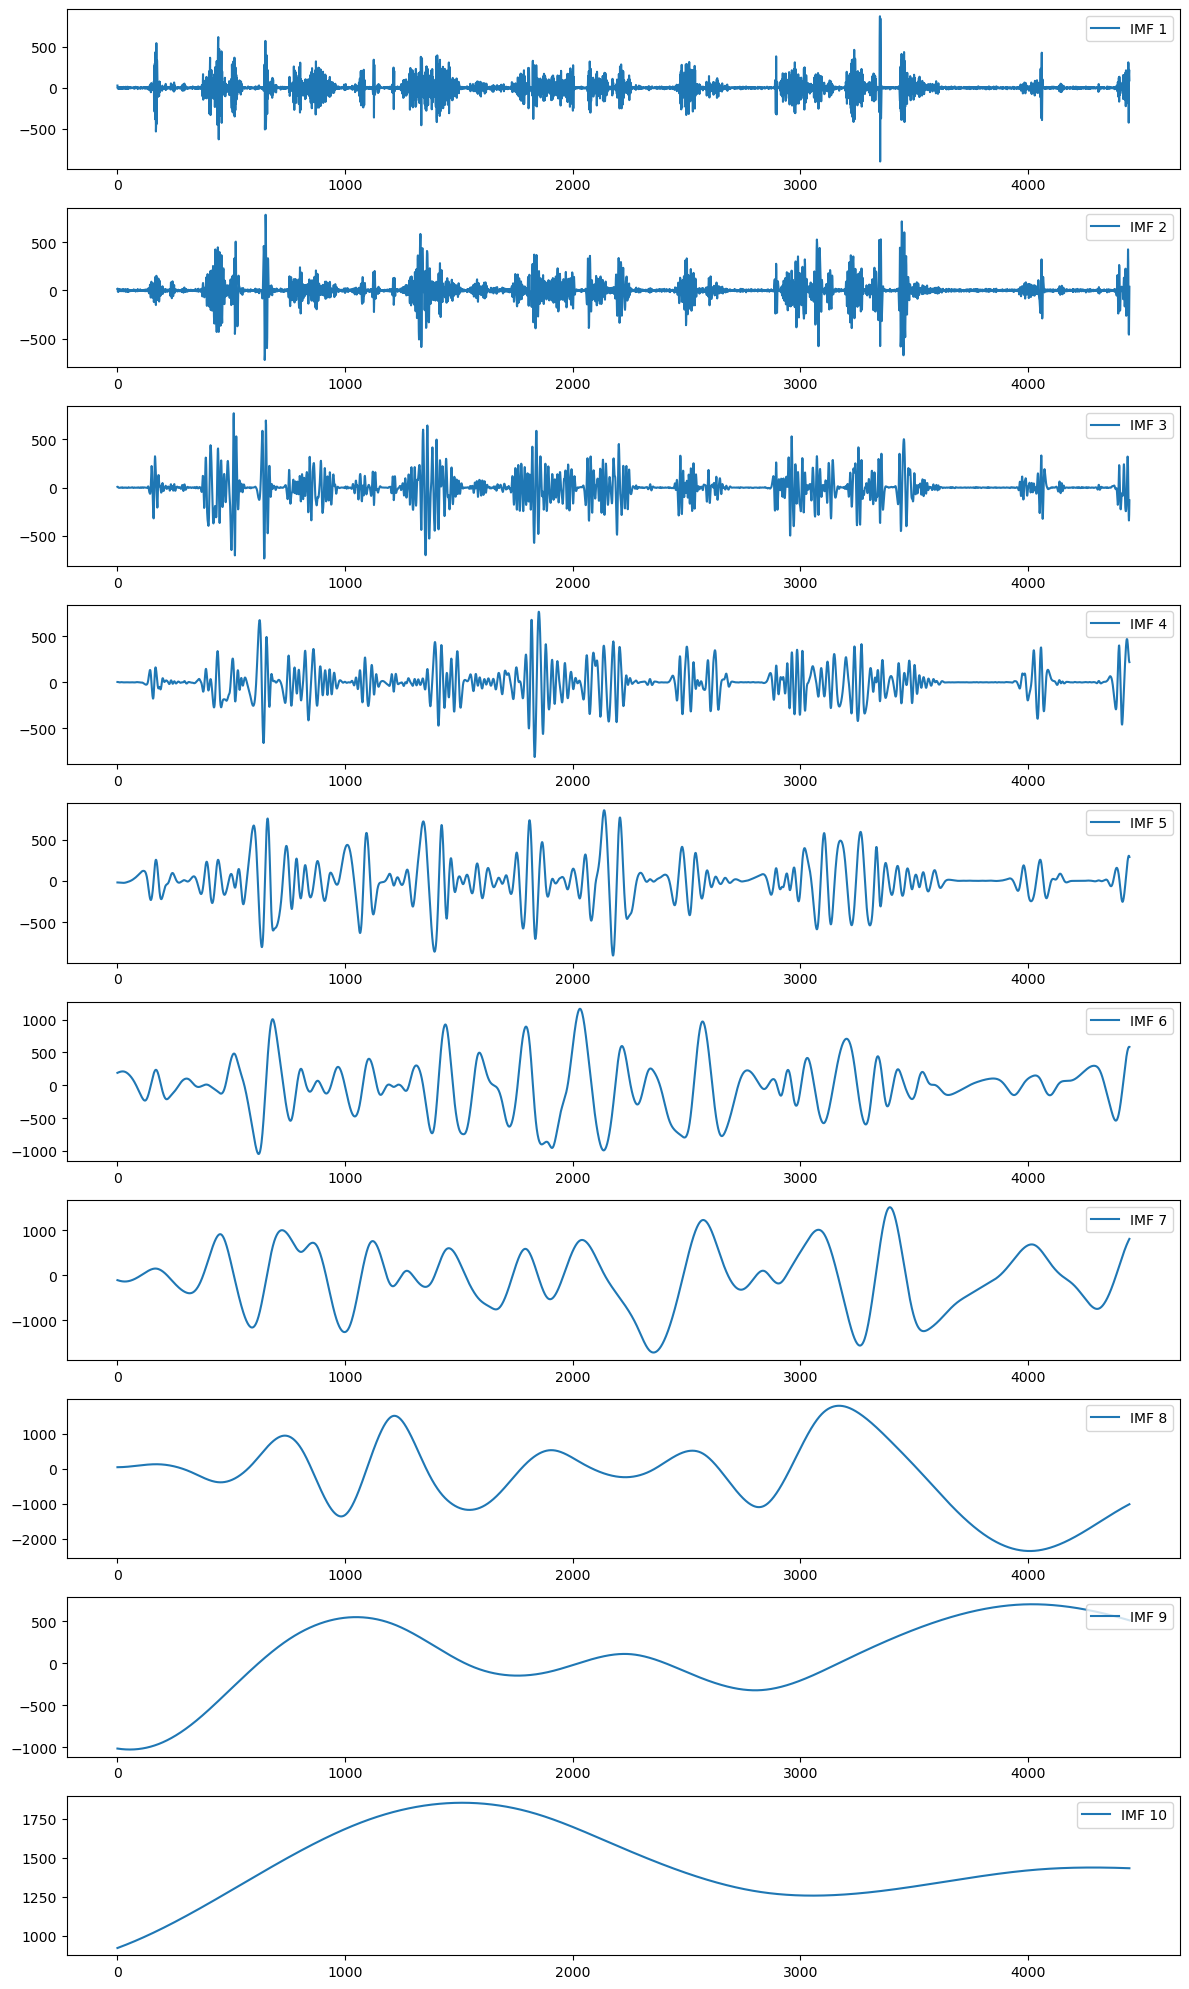

In [582]:
# Plot the CEEMDAN IMFs and the denoised signal
num_imfs = IMFs.shape[0]
plt.figure(figsize=(12, 2 * num_imfs))
for idx in range(num_imfs):
    plt.subplot(num_imfs, 1, idx + 1)
    plt.plot(ceemdan1.iloc[:, idx], label=f'IMF {idx + 1}')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

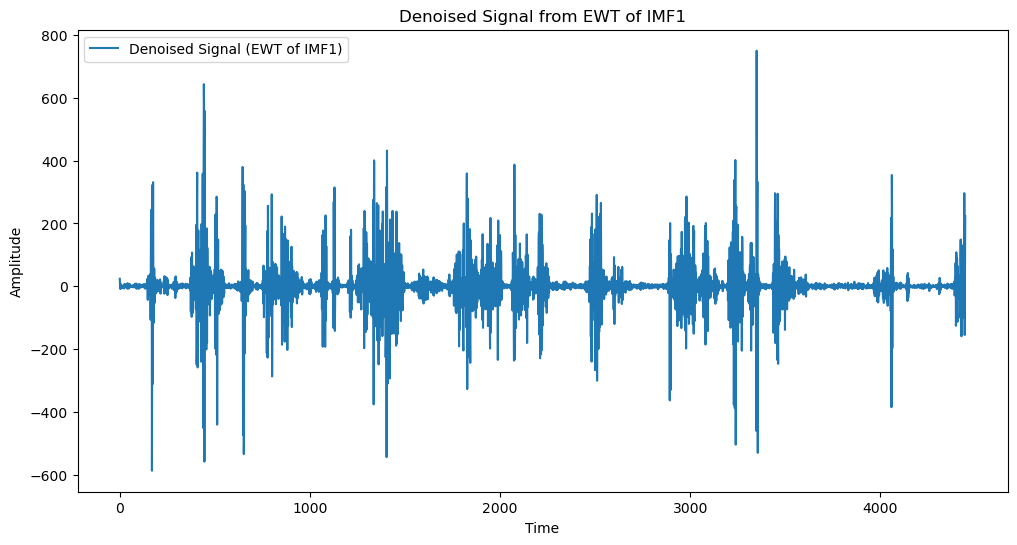

In [583]:
# Plot the denoised signal
plt.figure(figsize=(12, 6))
plt.plot(denoised, label='Denoised Signal (EWT of IMF1)')
plt.title('Denoised Signal from EWT of IMF1')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [584]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

## Step 3: Buidling the CEEMDAN-EWT with Transformer

In [585]:
# Define Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

# Define Transformer Model
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, num_layers=2, num_heads=2, d_model=128, dim_feedforward=128, dropout=0.2):
        super(TimeSeriesTransformer, self).__init__()
        self.d_model = d_model
        
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.encoder = nn.Linear(input_size, d_model)
        self.decoder = nn.Linear(d_model, 1)
        
    def forward(self, src):
        src = self.encoder(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output)
        return output

# Define Custom Dataset Class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        return x, y

In [586]:
# Initialize lists to store predictions and actual values
pred_test = []
test_ori = []
pred_train = []
train_ori = []

# Model parameters
epoch = 30
batch_size = 64
lr = 0.001
look_back = 12
early_stopping_patience = 10
data_partition = 0.8

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [587]:
for col in new_ceemdan:
    # Prepare dataset for the current component
    dataset_col = new_ceemdan[col].values.reshape(-1, 1)
    train_size = int(len(dataset_col) * data_partition)
    train, test = dataset_col[:train_size], dataset_col[train_size:]
    
    # Create datasets for training and testing
    trainX, trainY = create_dataset(train, look_back)
    testX, testY = create_dataset(test, look_back)
    
    if len(trainX) == 0 or len(testX) == 0:
        continue
    
    # Scale the data
    sc_X = StandardScaler()
    sc_y = StandardScaler()
    X_train = sc_X.fit_transform(trainX)
    y_train = sc_y.fit_transform(trainY.reshape(-1, 1)).ravel()
    X_test = sc_X.transform(testX)
    y_test = sc_y.transform(testY.reshape(-1, 1)).ravel()
    
    # Create datasets
    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    
    # Build the Transformer model
    model = TimeSeriesTransformer(input_size=1, num_layers=2, num_heads=4, d_model=256, dim_feedforward=256, dropout=0)
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, verbose=True)
    
    # Early stopping
    min_val_loss = float('inf')
    patience_counter = 0

    # Training loop
    for epoch_idx in range(epoch):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device).transpose(0, 1).unsqueeze(-1).float()
            batch_y = batch_y.to(device).float()

            optimizer.zero_grad()
            output = model(batch_X).squeeze(-1)
            output = output[-1]  # Get the last time step's output

            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device).transpose(0, 1).unsqueeze(-1).float() # [seq_len, batch_size, input_size]
                batch_y = batch_y.to(device).float() # [batch_size]
                output = model(batch_X).squeeze(-1) # [seq_len, batch_size]
                output = output[-1]
                val_loss += criterion(output, batch_y).item()

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')  # Save best model
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch_idx+1}')
            break

    # Load the best model for predictions
    model.load_state_dict(torch.load('best_model.pth'))

    # Collect predictions and actual values
    model.eval()
    y_pred_train_list = []
    y_train_list = []
    with torch.no_grad():
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device).transpose(0, 1).unsqueeze(-1).float()
            output = model(batch_X).squeeze(-1)
            output = output[-1]
            y_pred_train_list.append(output.cpu().numpy())
            y_train_list.append(batch_y.cpu().numpy())

    y_pred_test_list = []
    y_test_list = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device).transpose(0, 1).unsqueeze(-1).float()
            output = model(batch_X).squeeze(-1)
            output = output[-1]
            y_pred_test_list.append(output.cpu().numpy())
            y_test_list.append(batch_y.cpu().numpy())
    
    # Inverse transform predictions and actual values
    y_pred_train_inv = sc_y.inverse_transform(np.concatenate(y_pred_train_list).reshape(-1, 1))
    y_train_inv = sc_y.inverse_transform(np.concatenate(y_train_list).reshape(-1, 1))

    y_pred_test_inv = sc_y.inverse_transform(np.concatenate(y_pred_test_list).reshape(-1, 1))
    y_test_inv = sc_y.inverse_transform(np.concatenate(y_test_list).reshape(-1, 1))

    # Store predictions and actual values
    pred_train.append(y_pred_train_inv.flatten())
    pred_test.append(y_pred_test_inv.flatten())
    train_ori.append(y_train_inv.flatten())
    test_ori.append(y_test_inv.flatten())

c:\Users\aalma\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
c:\Users\aalma\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Early stopping at epoch 14


C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1535763405.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
c:\Users

Early stopping at epoch 25


C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1535763405.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
c:\Users

...

C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1535763405.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
c:\Users

Early stopping at epoch 23


C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1535763405.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
c:\Users

Early stopping at epoch 19


C:\Users\aalma\AppData\Local\Temp\ipykernel_5656\1535763405.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


In [588]:
# Convert lists to DataFrames
result_pred_test = pd.DataFrame(pred_test).T  # Transpose to align with actual values
result_pred_train = pd.DataFrame(pred_train).T

# Sum predictions across IMFs
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)


In [589]:
# Prepare actual data
dataset = dfs.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Prepare actual data for comparison
_, trainY = create_dataset(train, look_back)
_, testY = create_dataset(test, look_back)

# Scale the data
sc_y_total = StandardScaler()
y_train_scaled = sc_y_total.fit_transform(trainY.reshape(-1, 1))
y_test_scaled = sc_y_total.transform(testY.reshape(-1, 1))

# Inverse transform actual values
y_test_inv = sc_y_total.inverse_transform(y_test_scaled).flatten()
y_train_inv = sc_y_total.inverse_transform(y_train_scaled).flatten()

In [590]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]


# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = metrics.mean_absolute_error(y_test_series, a)
r2 = metrics.r2_score(y_test_series, a)


# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 115.419
MAE: 90.411
R2: 0.665


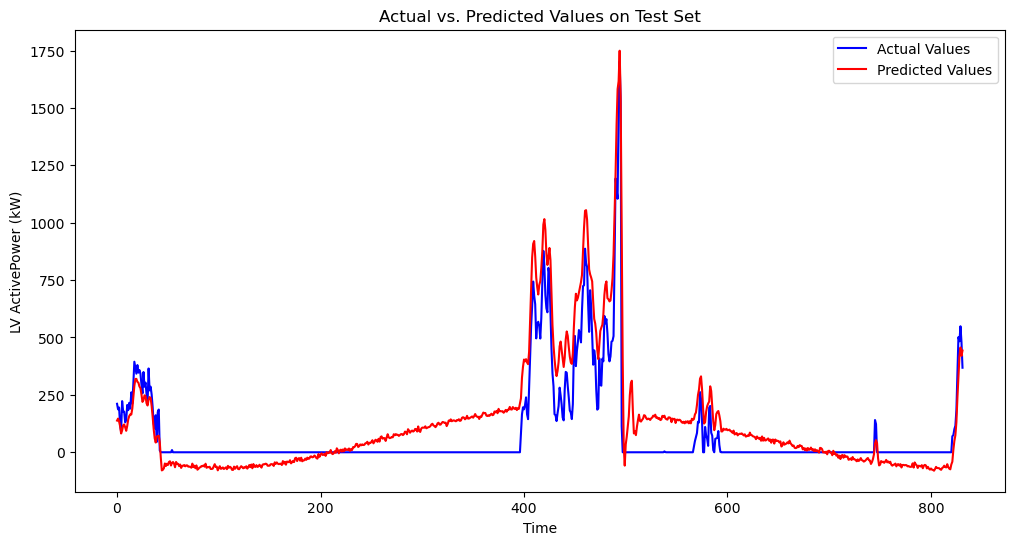

In [591]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()
